# Students Perfornmace Indicator


* Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
* The data consists of 8 column and 1000 rows


# Import Data and Required Packages

Importing Pandas m Numpy, Matplotlib, Seaborn and Warnings Library


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
import warnings
warnings.filterwarnings('ignore')

Import CSV data as Pandas DataFrame


In [15]:
df = pd.read_csv("data\StudentsPerformance.csv")

Show Top 5 Records

In [16]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Dataset Information
 * gender: sex of students-> Male/Female
 * race/ethnicity: ethnicity of students -> Group A/B/C/D
 * Parental level of education -> "bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'
 * Lunch: Lunch for Students-> Standard/(free/reduced)
 * test preparation course: courses taken by students-> Completed/None
 * Math score
 * Reading Score
 * writing score

Finding the Unique values from some columns of the dataset

In [21]:
df['parental level of education'].unique()


array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [22]:
df["race/ethnicity"].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [23]:
df["lunch"].unique()

array(['standard', 'free/reduced'], dtype=object)

In [24]:
df["test preparation course"].unique()

array(['none', 'completed'], dtype=object)

#checking missing values

In [27]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

No missing values found in the data set

# Check Duplicates

In [28]:
df.duplicated().sum()

np.int64(0)

No duplicates found in the data set

# Check Datatypes

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# Checking the Statistics of the data set

In [30]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# checking the unique values from each column

In [31]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

Defining numerical and categorial columns

In [39]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorial_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print("We have {} numerical features: {}".format(len(numerical_features),numerical_features))
print("\nWe have {} categorial features : {}".format(len(categorial_features),categorial_features))

We have 3 numerical features: ['math score', 'reading score', 'writing score']

We have 5 categorial features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


# Adding Columns for Total Score and Average Score

In [40]:
df['total score'] = df["math score"] + df["reading score"] + df["writing score"]
df["average"] = df["total score"]/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [43]:
math_full = (df["math score"] == 100).sum()
read_full = (df["reading score"] == 100).sum()
write_full = (df["writing score"] == 100).sum()

print(f"Number of students with full marks in maths are {math_full}")
print(f"Number of students with full marks in reading are {read_full}")
print(f"Number of students with full marks in writing are {write_full}")

Number of students with full marks in maths are 7
Number of students with full marks in reading are 17
Number of students with full marks in writing are 14


In [44]:
math_less_20 = (df["math score"]<= 20).sum()
read_less_20 = (df["reading score"]<= 20).sum()
write_less_20 = (df["writing score"]<= 20).sum()

print(f"Students scored less than 20 in math are {math_less_20}")
print(f"Students scored less than 20 in reading are {read_less_20}")
print(f"Students scored less than 20 in writing are {write_less_20}")

Students scored less than 20 in math are 4
Students scored less than 20 in reading are 1
Students scored less than 20 in writing are 3


# Data Visualization

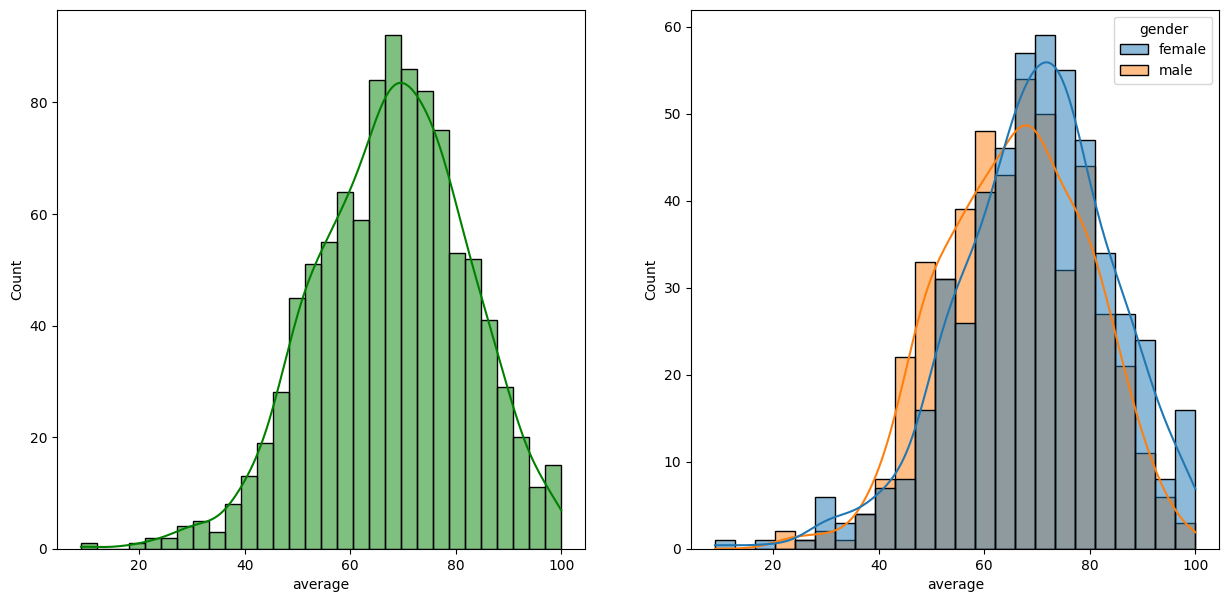

In [47]:
fig, axs = plt.subplots(1,2, figsize = (15,7))
plt.subplot(1,2,1)
sns.histplot(data=df,x = 'average',bins = 30,kde = True, color='g')
plt.subplot(1,2,2)
sns.histplot(data=df,x = "average",kde=True, hue = "gender")
plt.show()

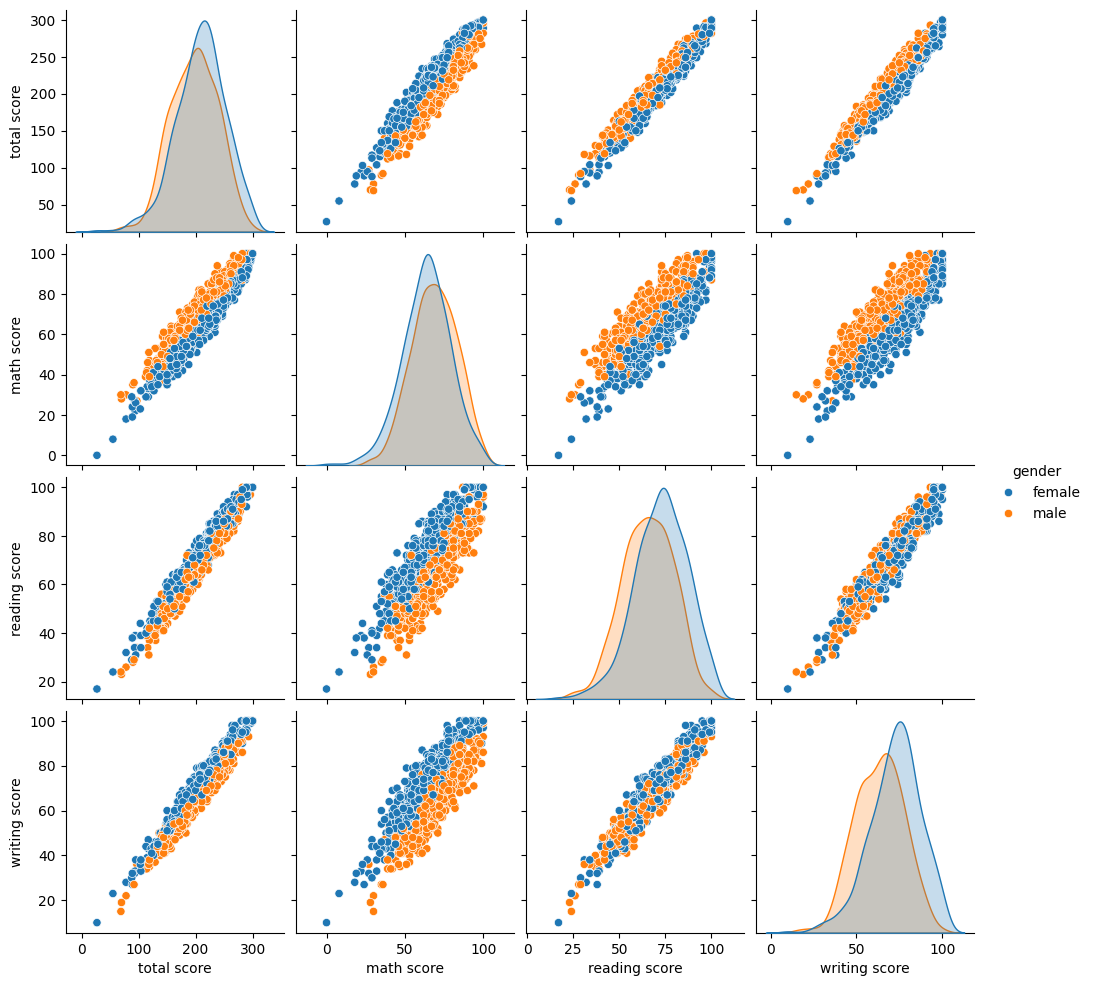

In [50]:
sns.pairplot(df,vars=["total score", "math score", "reading score", "writing score"],hue="gender")
plt.show()